In [277]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

Define multipole coefficients in a curved frame, then build $\vec{A}$, H and track.


curvature h[m^-1]:  1 radius of curvature [m]:  1.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543
nphi= 5


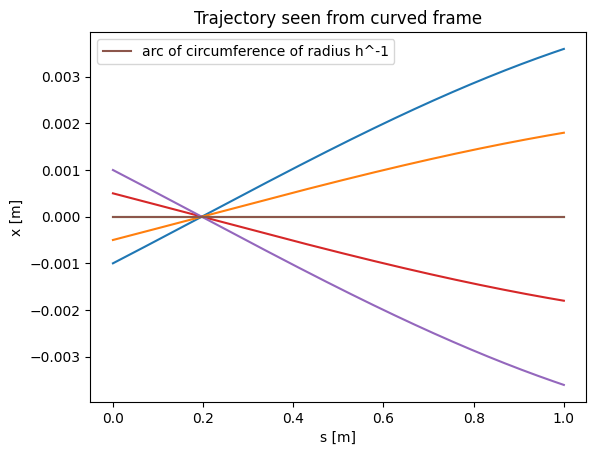

In [278]:
a_curved = [0,]
b_curved = [1, 0.2]
h= b_curved[0]# considering normalization B/Brho=1/rho=h            =1. if checking for a drift
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
p0 =xt.Particles(x=np.linspace(-1e-3, 1e-3, 5), y=0, s=0, py=np.linspace(0.005,-0.005,5), px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()
nphi=5
print("nphi=",nphi)
A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved, nphi=nphi)
H_curved = bpmeth.Hamiltonian(length=1, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory seen from curved frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

Then work at the level of the scalar potential because being a scalar it is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, checking how the a,b coefficients look in that frame.

In [279]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  -y**5*(0.2*x + 0.2)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) + y**3*(0.2*x + 0.2)/(6*(1.0*x + 1)**2) - y*(0.2*x + 1)

phi straight frame:  -0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0) + 0.0333333333333333*y**3/sqrt(s**2 + (x + 1.0)**2) - y*(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)

Bx straight frame:  0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)

Remembering that $ \phi_0(x, s) = -a_0(s) - \sum_{n=1}^\infty a_n(s) \frac{x^n}{n!} \\
    \phi_1(x, s) = -\sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}  $

Take the coefficient of y in phi_straight, which is $\phi_1$, expand it in a Taylor series in x around 0 up to some order, e.g. 4, (strip the big-O), and store the resulting polynomial’s coefficients in a dictionary keyed by powers of x. This corresponds to

 $\frac{b_n}{(n-1)!}$

 and the same for $a_n$ considering that \\
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)$
.

phi1= -(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)


<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_46153/4029977930.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.title("b(s) in straight frame from transformation of $\phi$")
/tmp/fmarcoli/ipykernel_46153/4029977930.py:89: SyntaxWarning: invalid escape sequence '\p'
  plt.title("a(s) in straight frame from transformation of $\phi$")


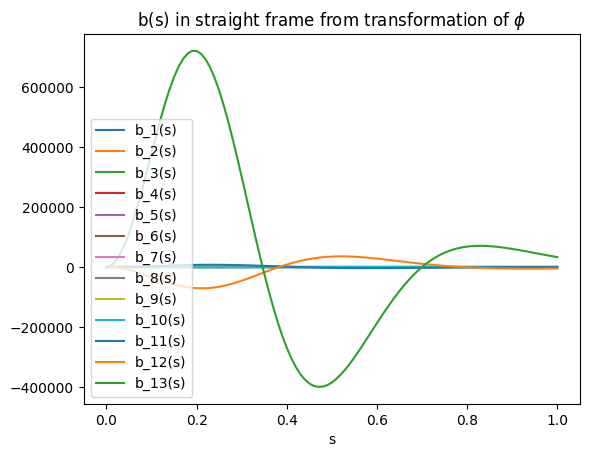

phi0= 0


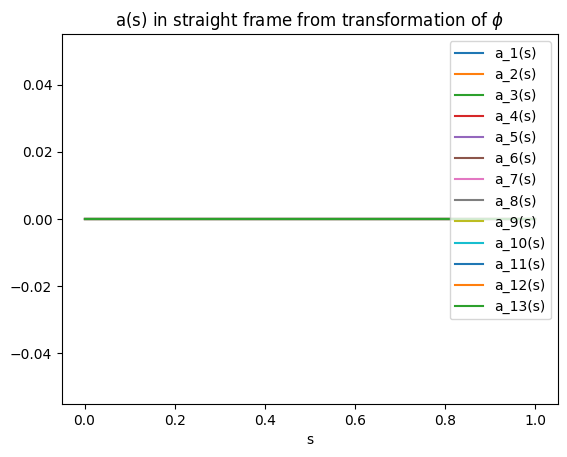

In [280]:
maxordx=12
ns=101
phi1=phi_straight.as_coefficients_dict(y)[y]
print("phi1=",phi1) 
ss = np.linspace(0, 1, ns)
if phi1==0:
    # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
  
    b_vals = np.zeros((maxordx+1, ss.size))
else:
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
if phi1 != 0:
    # 2. Nontrivial phi0: do series in x and extract b_n(s)
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)

    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_b):
        if k == 0:
            b_k = -vv                    # b_1(s)
            label = "b_1(s)"
        else:
            b_k = -vv * sp.factorial(k)  # b_k(s)
            label = f"b_{k+1}(s)"

        b_fun = sp.lambdify(s, b_k, 'numpy')
        b_vals[k, :] = b_fun(ss)

        plt.plot(ss, b_vals[k, :], label=label)
else:
    # 3. phi1 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"b_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, b_vals[k, :], label=label)

plt.legend()
plt.title("b(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()
############################################
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
print("phi0=",phi0)        # you'll see 0 in this case

if phi0 == 0:
    # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
    #ss = np.linspace(0, 1, ns)
    a_vals = np.zeros((maxordx+1, ss.size))
else:
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
if phi0 != 0:
    # 2. Nontrivial phi0: do series in x and extract a_n(s)
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)

    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_a):
        if k == 0:
            a_k = -vv                    # a_0(s)
            label = "a_1(s)"
        else:
            a_k = -vv * sp.factorial(k)  # a_k(s)
            label = f"a_{k+1}(s)"

        a_fun = sp.lambdify(s, a_k, 'numpy')
        a_vals[k, :] = a_fun(ss)

        plt.plot(ss, a_vals[k, :], label=label)
else:
    # 3. phi0 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"a_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, a_vals[k, :], label=label)

plt.legend()
plt.title("a(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()

In [281]:
# evaluate fields on cartesian grid 
xstraightarray = np.linspace(-1, 1, 100)
ystraightarray = np.linspace(-1, 1, 100)
sstraightarray = ss  # same s array used before

Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_ana_array = np.broadcast_to(Bxstraight_ana_array, shape).copy()
Bystraight_ana_array = np.broadcast_to(Bystraight_ana_array, shape).copy()
Bsstraight_ana_array = np.broadcast_to(Bsstraight_ana_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_ana_array.shape)
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
#fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA, sample the field on a cylindrical grid
ntheta=128
nr=40
def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d, rmin=0.001, rmax=0.4, nr=128,ntheta=256, ns=40):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, theta_1d, fields
rr, theta_1d, cylfieldatadict= interp_cartesian_to_cylindrical(datastraightfm, x_1d=xstraightarray, y_1d=ystraightarray, s_1d=sstraightarray, rmin=0.001, rmax=0.5, nr=nr, ntheta=ntheta, ns=ns)
rarr, tarr, sarr = np.meshgrid(rr, theta_1d, sstraightarray, indexing='ij')
cylfieldmapdatastack= np.column_stack([rarr.ravel(), tarr.ravel(), sarr.ravel(), cylfieldatadict['Bx'].ravel(), cylfieldatadict['By'].ravel(), cylfieldatadict['Bs'].ravel()])

<lambdifygenerated-1268>:2: RuntimeWarning: invalid value encountered in divide
  return 0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)**2 + 0.00166666666666667*y**5*(x + 1.0)/(sqrt(s**2 + (x + 1.0)**2)*(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)) - 0.0333333333333333*y**3*(-x - 1.0)/(s**2 + (x + 1.0)**2)**(3/2) + 0.2*y*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2)
<lambdifygenerated-1269>:2: RuntimeWarning: invalid value encountered

(100, 100, 101)


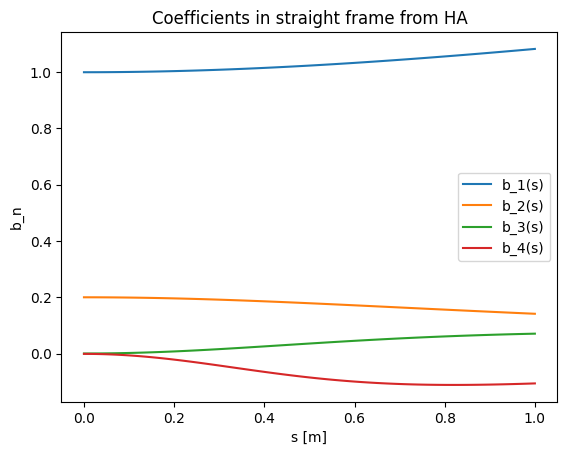

In [282]:
fm_straight_cyl= bpmeth.fieldmaps.Fieldmap(cylfieldmapdatastack)
orderHA=4
svals, astraightofs, bstraightofs, erroras, errorbs = fm_straight_cyl.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=orderHA)
for i, b in enumerate(bstraightofs.T):
    plt.plot(svals, b, label=f"b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n')
plt.title('Coefficients in straight frame from HA')
plt.legend()
plt.show()

As expected an s dependence appeared. To asses the importance of not neglecting it we can see what are the predictions of a naive tracking that would disregard the effect of curvature compared with a more advanced one. 

We can make a quality check on the HA by plotting the difference of its result with the results from the analytical expansion of $\phi$

4
4 13


<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/tmp/fmarcoli/ipykernel_46153/386023216.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta$b_{i+1}(s)")
/tmp/fmarcoli/ipykernel_46153/386023216.py:15: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")


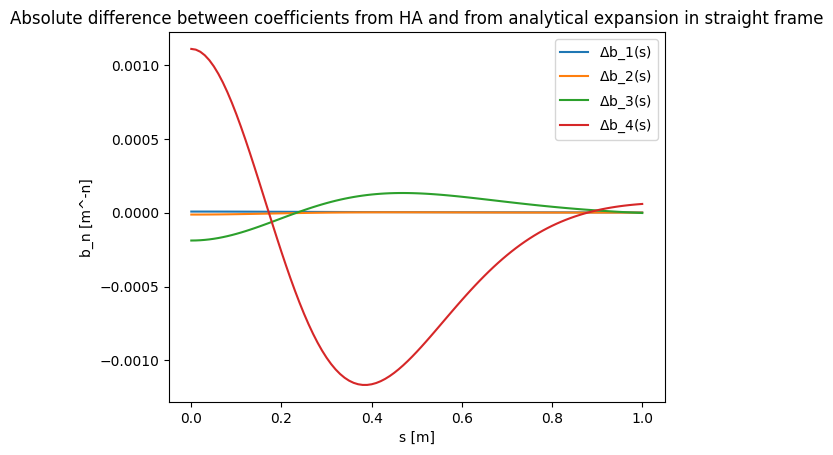

/tmp/fmarcoli/ipykernel_46153/386023216.py:13: RuntimeWarning: divide by zero encountered in divide
  reldeltab=deltab/b_vals[:commonsize]


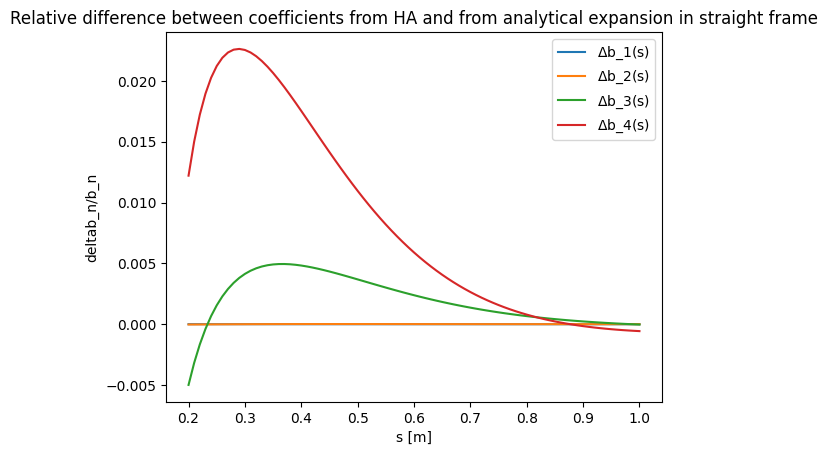

In [283]:
commonsize=min(bstraightofs[0].size,b_vals.T[0].size)
print(commonsize)
print(bstraightofs[0].size,b_vals.T[0].size)
deltab=b_vals[:commonsize,:]-bstraightofs.T[:commonsize,:] #note that b_vals includes b_0 while bstraightofs starts from b_1
for i, d in enumerate(deltab[:maxordx]):
    plt.plot(svals, d, label=f"$\Delta$b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n [m^-n]')
plt.title('Absolute difference between coefficients from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

reldeltab=deltab/b_vals[:commonsize]
for i, d in enumerate(reldeltab[:maxordx]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between coefficients from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

The result from the HA is quite good up to order 6. It would be a good idea to see if this high order imperfections actually account for some deviations in the predicted trajectory.

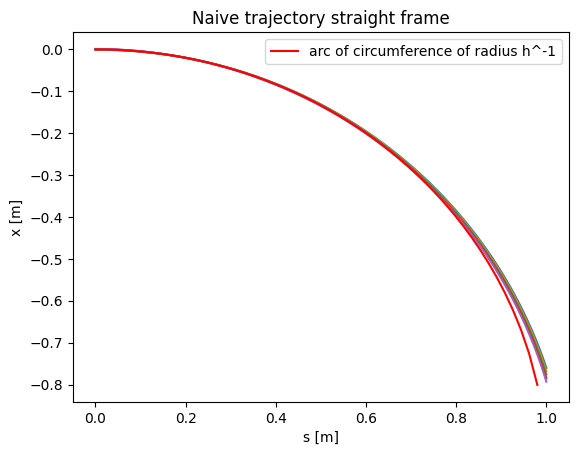

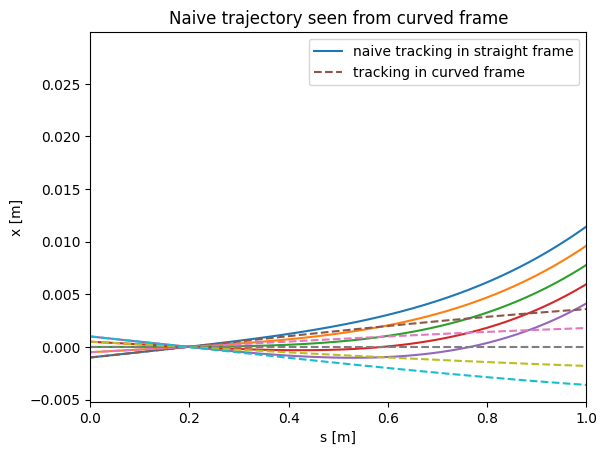

In [284]:
Astrnaive=bpmeth.GeneralVectorPotential(h=0, b=b_curved, a=a_curved, nphi=5)#uses the original simple coefficients disregarding the curvature
Hstrnaive = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrnaive)
p_2 = p0.copy()
sol_strnaive = Hstrnaive.track(p_2, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strnaive:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory straight frame")
x=np.linspace(0,.98,55)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
#plt.xlim((0., 0.99))
plt.show()

#visualise from the pov of the curved frame
for i, ss in enumerate(sol_strnaive):
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    if i == 0:
        plt.plot(sc,xc, label='naive tracking in straight frame')
    else:
        plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for i,ss in enumerate(sol_curved):
    if i == 0:
        plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
    else:
        plt.plot(ss.t, ss.y[0],'--')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()

If we want to be more precise we can stay in the straight frame but account for the s dependence of the coefficients

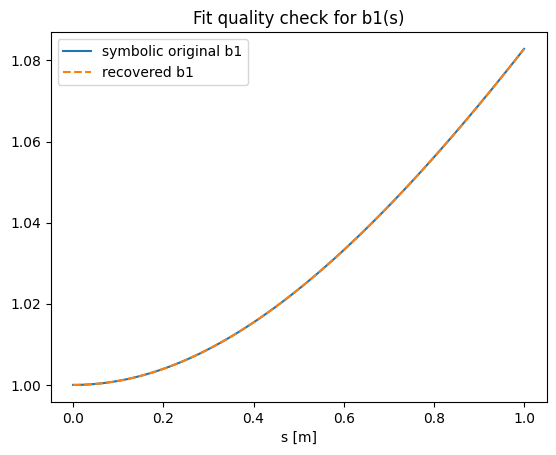

In [285]:
# Use a Chebyshev basis on [0,1] and a moderate degree to reduce ill-conditioning.
degree = 10
b_nfit = []
a_nfit = []

s = sp.symbols('s')

for arr, dst in [(bstraightofs, b_nfit), (astraightofs, a_nfit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(str(sp.expand(poly_expr)))


plt.plot(sstraightarray, bstraightofs[:,0], label="symbolic original b1")
b1ofslambdified = sp.lambdify(s, b_nfit[0], modules='numpy')
b1_eval = b1ofslambdified(sstraightarray)
b1_eval = np.broadcast_to(b1_eval, sstraightarray.shape)  # works for scalar or array
plt.plot(sstraightarray, b1_eval,'--', label='recovered b1')
plt.legend()
plt.title("Fit quality check for b1(s)")
plt.xlabel('s [m]')
plt.show()


In [286]:
Astrbetter=bpmeth.GeneralVectorPotential(h=0, b=b_nfit, a=a_nfit, nphi=orderHA+2)#accounts for the s dependence of the coefficients
Hstrbetter = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrbetter)
p_3 = p0.copy()
sol_strbetter = Hstrbetter.track(p_3, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

<lambdifygenerated-1291>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**6*(-0.0652543707353578*s**7 + 0.0887768466809192*s**6 + 0.157772996551647*s**5 - 0.405486759137643*s**4 + 0.306077869115384*s**3 - 0.0871383003056942*s**2 + 0.00564941689078637*s + (1/4320)*x**3*(-1414.37864466956*s**5 + 22053.3455997142*s**4 - 44761.2976650675*s**3 + 32925.7964053398*s**2 - 9193.93917964308*s + 660.180064041352) + (1/1440)*x**2*(-986.64608551861*s**5 + 958.789944153927*s**4 + 1315.65253011626*s**3 - 1947.50426877752*s**2 + 664.08005438598*s - 35.499070599283) + (1/720)*x*(26.8941240234555*s**5 + 53.7428005313735*s**4 - 258.407523843778*s**3 + 258.01439690092*s**2 - 79.1253988111915*s + 0.77593699186623) + (1/360)*x*(-33.6756820159418*s**7 + 735.111519990473*s**6 - 2238.06488325337*s**5 + 2743.81636711165*s**4 - 1532.32319660718*s**3 + 330.090032020676*s**2 - 6.55397953113494*s + 1.09963683464275) - 0.000415067288819408) - y**5*(1.63068056236219e-12*s**9 - 7.7026841710901

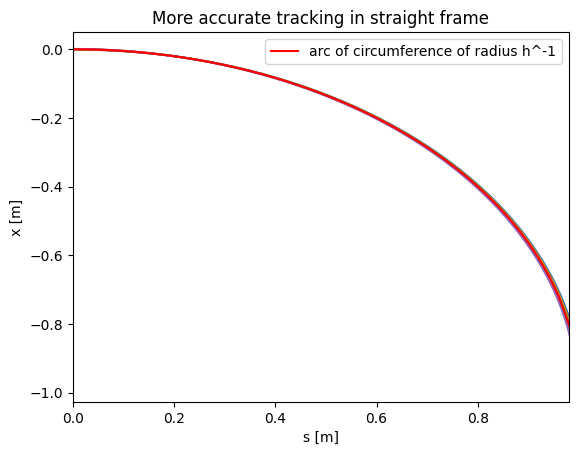

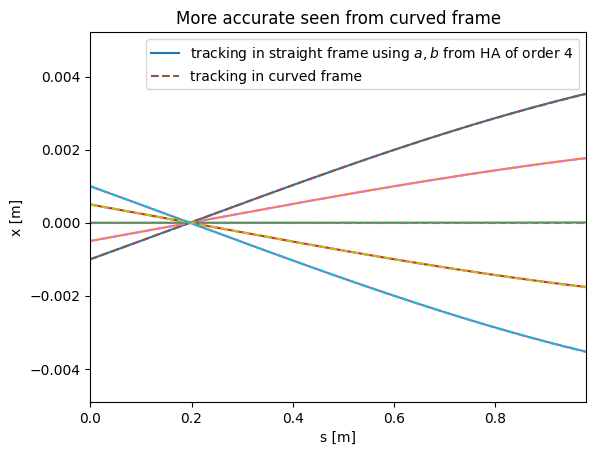

In [287]:
#plot trajectories tracked in straight frame
for ss in sol_strbetter:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking in straight frame")
x=np.linspace(0,.98,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()
#visualise from the pov of the curved frame
for i,ss in enumerate(sol_strbetter):
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    if i==0:
        plt.plot(sc,xc, label='tracking in straight frame using $a,b$ from HA of order '+str( bstraightofs[0].size))
    else:
        plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for i,ss in enumerate(sol_curved):
    if i ==0:
        plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
    else:
        plt.plot(ss.t, ss.y[0],'--')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()

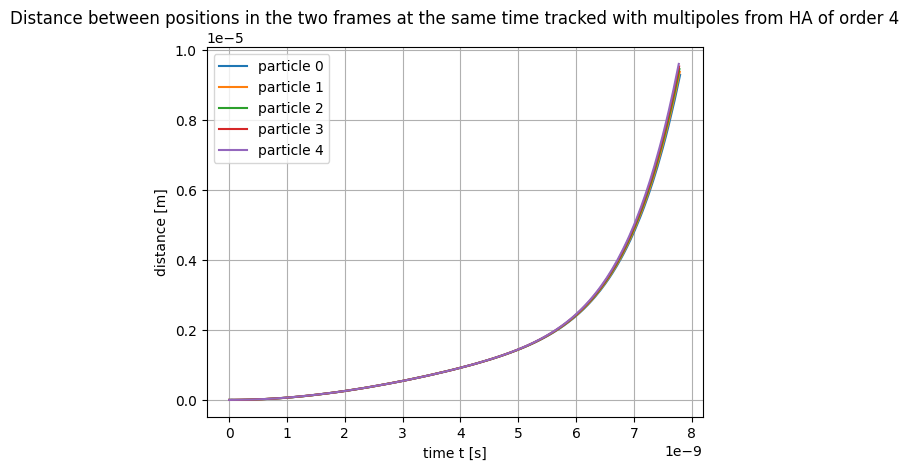

In [288]:
#project the coordinates tracked in the two frames onto a global frame (corresponding to the straight frame in practice)
from scipy.interpolate import PchipInterpolator
import numpy as np
import matplotlib.pyplot as plt

rho = 1.0 / h
c = 299792458.0

def global_from_straight(sb, beta0):
    s = sb.t
    x = sb.y[0]
    tau = sb.y[2]

    t = (s / beta0 - tau) / c

    X = x
    Z = s
    return t, X, Z

def global_from_curved(sa, beta0, h):
    rho = 1.0 / h
    s = sa.t
    x = sa.y[0]
    tau = sa.y[2]

    t = (s / beta0 - tau) / c

    X = -rho + (rho + x) * np.cos(h * s)
    Z = (rho + x) * np.sin(h * s)

    return t, X, Z


plt.figure()
all_dt = []

for i, (sb, sa) in enumerate(zip(sol_strbetter, sol_curved)):
    t_str, X_str, Z_str = global_from_straight(sb, beta0)
    t_cur, X_cur, Z_cur = global_from_curved(sa, beta0, h)

    # sort by time
    idx_str = np.argsort(t_str)
    idx_cur = np.argsort(t_cur)

    t_str = t_str[idx_str]
    X_str = X_str[idx_str]
    Z_str = Z_str[idx_str]

    t_cur = t_cur[idx_cur]
    X_cur = X_cur[idx_cur]
    Z_cur = Z_cur[idx_cur]

    # common time interval
    t_min = max(t_str.min(), t_cur.min())
    t_max = min(t_str.max(), t_cur.max())

    if t_max <= t_min:
        continue

    t_common = np.linspace(t_min, t_max, 500)

    # PCHIP interpolation
    X_str_t = PchipInterpolator(t_str, X_str)(t_common)
    Z_str_t = PchipInterpolator(t_str, Z_str)(t_common)

    X_cur_t = PchipInterpolator(t_cur, X_cur)(t_common)
    Z_cur_t = PchipInterpolator(t_cur, Z_cur)(t_common)

    # distance for this particle
    d_t = np.sqrt((X_str_t - X_cur_t)**2 + (Z_str_t - Z_cur_t)**2)
    all_dt.append((t_common, d_t))

    plt.plot(t_common, d_t, label=f"particle {i}")

plt.xlabel("time t [s]")
plt.ylabel("distance [m]")
plt.grid(True)
plt.legend()
plt.title("Distance between positions in the two frames at the same time tracked with multipoles from HA of order "+str(orderHA))
plt.show()

particle 0: dx_exit = 8.449e-06 m, RMS_x = 3.686e-06 m
particle 1: dx_exit = 8.638e-06 m, RMS_x = 3.719e-06 m
particle 2: dx_exit = 8.754e-06 m, RMS_x = 3.752e-06 m
particle 3: dx_exit = 8.766e-06 m, RMS_x = 3.783e-06 m
particle 4: dx_exit = 8.638e-06 m, RMS_x = 3.813e-06 m


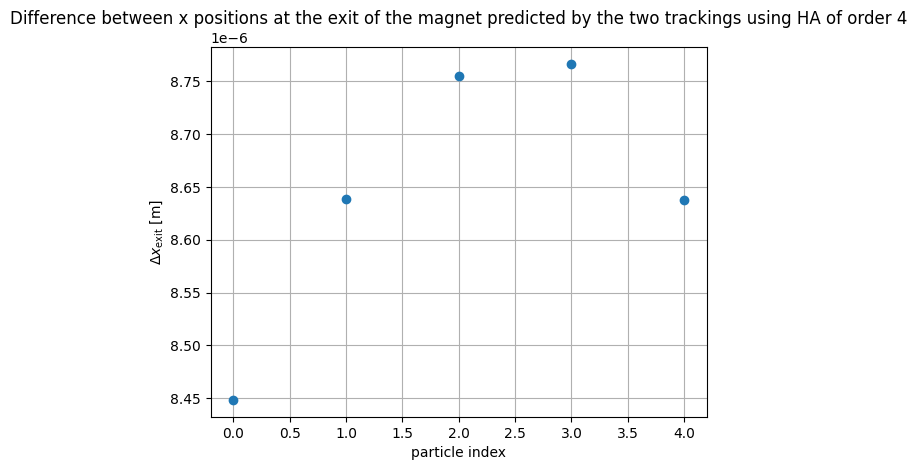

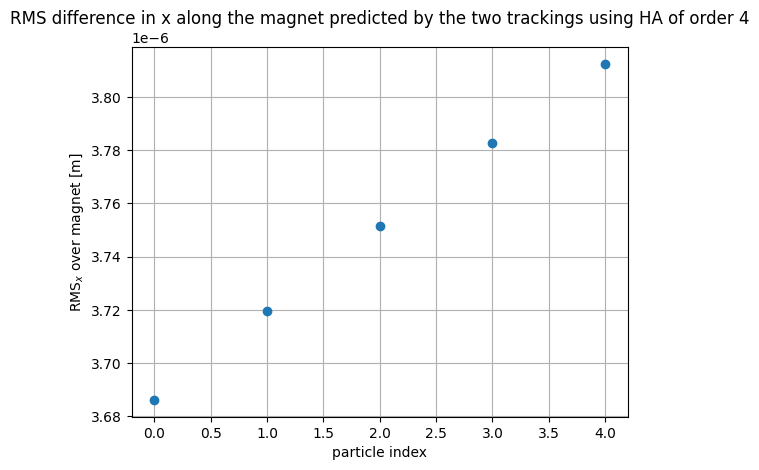

In [289]:
sbar_fin = 0.8         # chosen exit position in straight frame [m], for some reason its ok until 0.7m

dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strbetter, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )


plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using HA of order '+str(orderHA))
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.title('RMS difference in x along the magnet predicted by the two trackings using HA of order '+str(orderHA))
plt.grid(True)
plt.show()

Let's do the same for the coefficients from the transformation of $\phi$ instead than from HA.

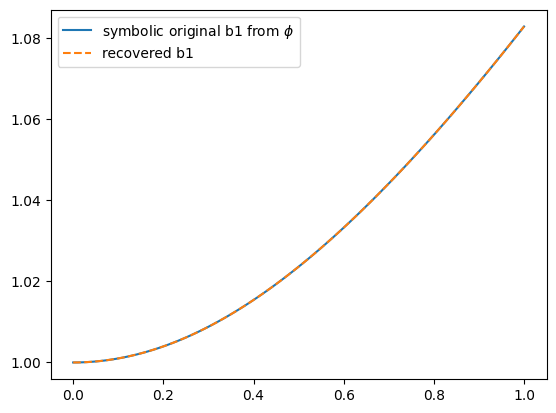

In [290]:
b_fromphifit = []
a_fromphifit = []
s = sp.symbols('s')

for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
# use b_fromphifit (not b_nfit), index 0 = b_1(s)
b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray), '--', label='recovered b1')
plt.legend()
plt.show()

do the tracking with the coefficients from phi

<lambdifygenerated-1311>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**16*(1.40171228370401*s**7 - 5.51793273236021*s**6 + 8.94611737601959*s**5 - 7.88584554423997*s**4 + 4.08876348375142*s**3 - 1.23515330515452*s**2 + 0.196207315932391*s - 1/430411677696000*x**6*(1.18749134237442e+16 - 2.11159667486647e+16*s) - 1/71735279616000*x**5*(859979379864959.0*s - 526991729971881.0) - 1/14347055923200*x**4*(15444520773277.7 - 17712823390859.2*s) - 1/14347055923200*x**4*(-3.51932779144412e+15*s**3 + 5.93745671187208e+15*s**2 - 3.15562268705903e+15*s + 519359772804809.0) - 1/3586763980800*x**3*(441726374867.579 - 1696343547879.87*s) - 1/3586763980800*x**3*(143329896644160.0*s**3 - 263495864985941.0*s**2 + 152102833964052.0*s - 27117554449716.2) - 1/1195587993600*x**2*(324306530214.348*s - 141111652244.246) - 1/1195587993600*x**2*(-2952137231809.87*s**3 + 7722260386638.87*s**2 - 5659138253728.9*s + 1206410560547.32) - 1/1992646656000*x**2*(-175966389572206.0*s**5 + 494

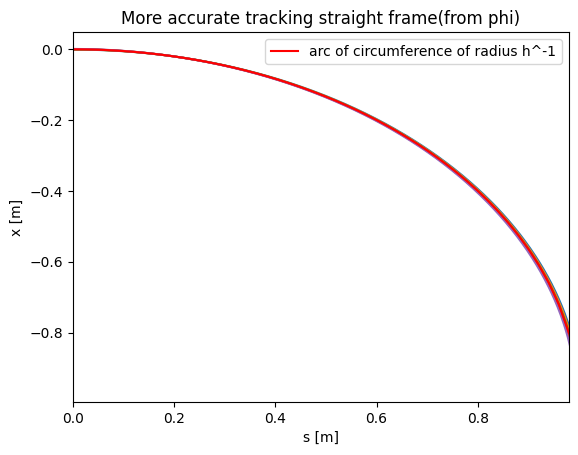

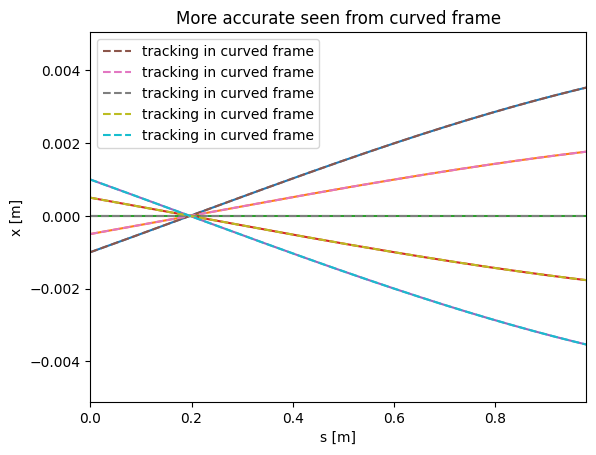

In [291]:
Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#accounts for the s dependence of the coefficients
Hstrfromphi = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrfromphi)
p_4 = p0.copy()
sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strfromphi:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame(from phi)")
x=np.linspace(0,.98,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.xlim((0., .98))#because H curved has length 1
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strfromphi:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()

particle 0: dx_exit = -6.130e-07 m, RMS_x = 7.178e-10 m
particle 1: dx_exit = -6.753e-07 m, RMS_x = 6.896e-10 m
particle 2: dx_exit = -8.174e-07 m, RMS_x = 6.539e-10 m
particle 3: dx_exit = -1.071e-06 m, RMS_x = 6.364e-10 m
particle 4: dx_exit = -1.472e-06 m, RMS_x = 6.241e-10 m


<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_46153/2097916680.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
/tmp/fmarcoli/ipykernel_46153/2097916680.py:71: SyntaxWarning: invalid escape sequence '\p'
  plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))


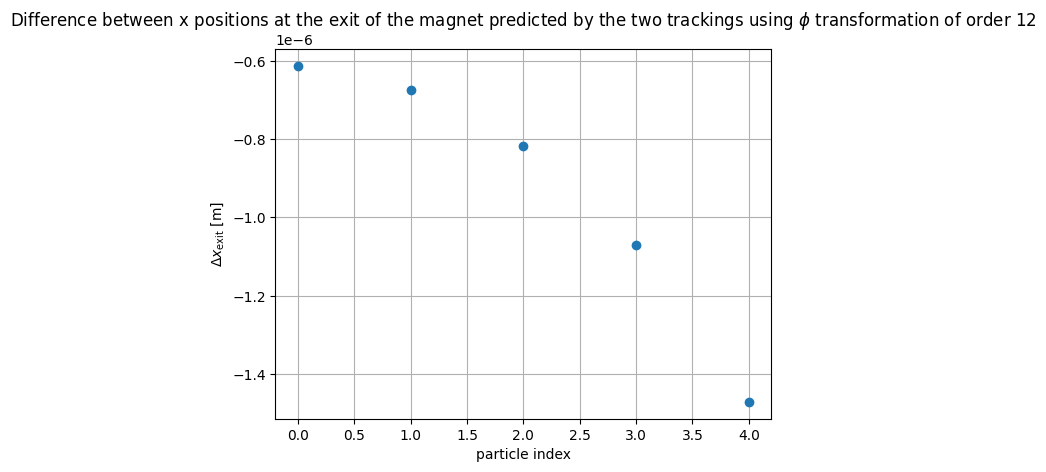

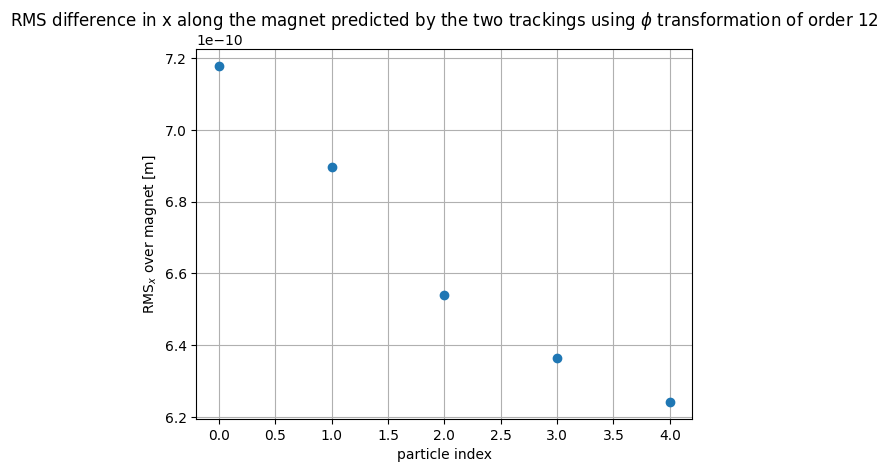

average final delta x between particles using phi transf. of order 12=-9.297064702873392e-07
average RMS x between particles using phi transf. of order 12=6.643578750089597e-10


In [292]:
sbar_fin = 0.8         # chosen exit position in straight frame [m], for some reason its ok until 0.7m

dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)
plt.show()

print("average final delta x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(dx_exit_list)))
print("average RMS x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(rms_x_list)))

<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_46153/2020633304.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Distance between tracked positions using $\phi$ transf. of order "+str(maxordx))


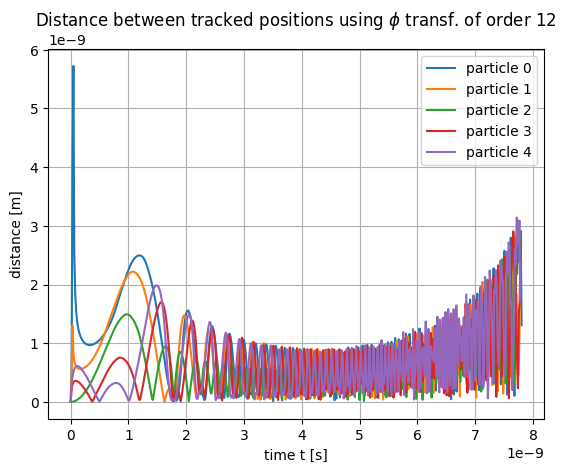

In [293]:
#project the coordinates tracked in the two frames onto a global frame (corresponding to the straight frame in practice)

plt.figure()
all_dt = []

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    t_str, X_str, Z_str = global_from_straight(sb, beta0)
    t_cur, X_cur, Z_cur = global_from_curved(sa, beta0, h)

    # sort by time
    idx_str = np.argsort(t_str)
    idx_cur = np.argsort(t_cur)

    t_str = t_str[idx_str]
    X_str = X_str[idx_str]
    Z_str = Z_str[idx_str]

    t_cur = t_cur[idx_cur]
    X_cur = X_cur[idx_cur]
    Z_cur = Z_cur[idx_cur]

    # common time interval
    t_min = max(t_str.min(), t_cur.min())
    t_max = min(t_str.max(), t_cur.max())

    if t_max <= t_min:
        continue

    t_common = np.linspace(t_min, t_max, 500)

    # PCHIP interpolation
    X_str_t = PchipInterpolator(t_str, X_str)(t_common)
    Z_str_t = PchipInterpolator(t_str, Z_str)(t_common)

    X_cur_t = PchipInterpolator(t_cur, X_cur)(t_common)
    Z_cur_t = PchipInterpolator(t_cur, Z_cur)(t_common)

    # distance for this particle
    d_t = np.sqrt((X_str_t - X_cur_t)**2 + (Z_str_t - Z_cur_t)**2)
    all_dt.append((t_common, d_t))

    plt.plot(t_common, d_t, label=f"particle {i}")

plt.xlabel("time t [s]")
plt.ylabel("distance [m]")
plt.grid(True)
plt.legend()
plt.title("Distance between tracked positions using $\phi$ transf. of order "+str(maxordx))
plt.show()

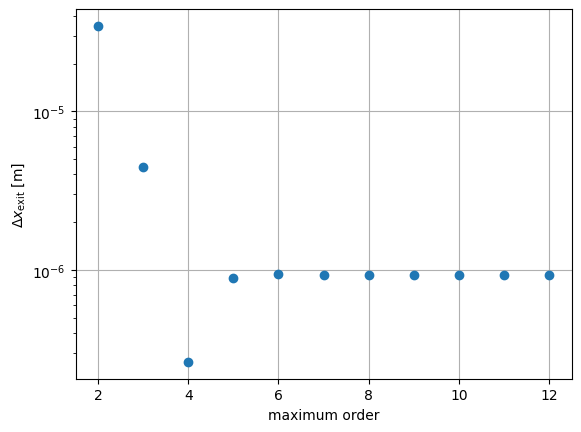

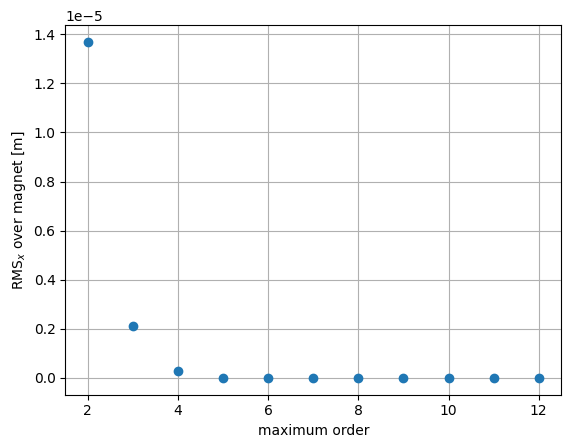

In [297]:
orders=np.linspace(2,12,11)
rmsxoforder=[1.3688053980274545e-05,
2.1199039399123123e-06,
2.6477495151701977e-07,
1.46353475595529e-08,
5.63768740171125e-9,
2.5409950505022127e-09,
8.808186741951285e-10,
6.671491653629608e-10,
6.643795995266129e-10,
6.645145276699899e-10,
6.643578750089597e-10]
deltaxfoforder=[3.45470570721762e-05,
4.431476254784794e-06,
-2.6323317281473635e-07,
-8.864868036861928e-07,
-9.386604379213459e-07,
-9.342282296542769e-07,
-9.308368066562877e-07,
-9.298888897113499e-07,
-9.297169580091414e-07,
-9.29702647578523e-07,
-9.297064702873392e-07
]
plt.plot(orders[:], np.abs(deltaxfoforder[:]), "o")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.grid(True)
plt.show()

plt.plot(orders[:], rmsxoforder[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.grid(True)
plt.show()


TESTING MULTIPLE MODELS FOR RMS_X CURVE

1. EXPONENTIAL DECAY: y = a * exp(-b * x)
   a = 5.818410e-04, b = 1.874778
   R² = 0.999971, RMSE = 2.112130e-08

2. POWER LAW: y = a * x^(-b)
   a = 3.746244e-04, b = 4.773455
   R² = 0.999364, RMSE = 9.863558e-08

3. STRETCHED EXPONENTIAL: y = a * exp(-(b*x)^c)
   a = 1.808742e-04, b = 1.014039, c = 1.341112
   R² = 0.999999, RMSE = 4.003630e-09

4. INVERSE LOGARITHMIC: y = a / (log(x))^b
   a = 2.648030e-06, b = 4.486085
   R² = 0.997426, RMSE = 1.984868e-07

5. POLYNOMIAL DECAY: y = a / (1 + b*x^c)
   a = 1.813323e-05, b = 0.001498, c = 7.759939
   R² = 0.999993, RMSE = 9.997465e-09

6. EXPONENTIAL WITH FLOOR: y = a * exp(-b * x) + floor
   a = 5.769412e-04, b = 1.870245, floor = -8.551859e-09
   R² = 0.999974, RMSE = 1.977439e-08

MODEL RANKING BY R²
1. Stretched Exp        | R² = 0.99999895 | RMSE = 4.003630e-09
2. Poly Decay           | R² = 0.99999347 | RMSE = 9.997465e-09
3. Exp w/ Floor         | R² = 0.99997445 | RMSE = 1.977439e-08


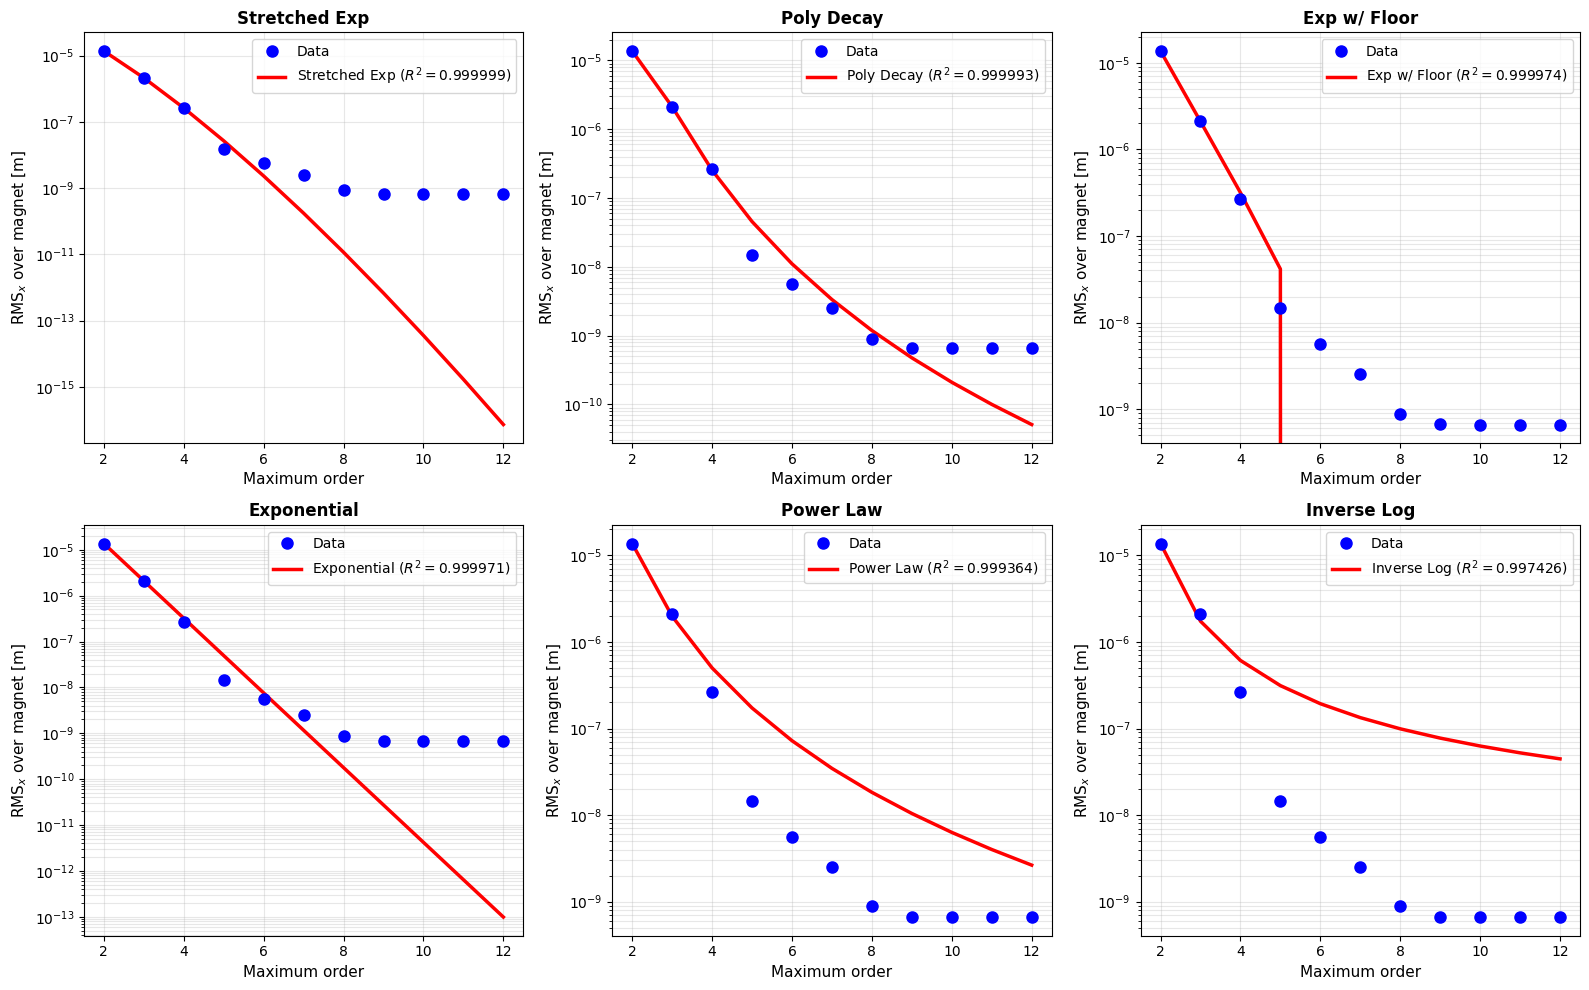


INTERPRETATION

Best fit: Stretched Exp
R² = 0.99999895

The plateau in the RMS curve (orders 7-12) indicates:
- Exponential decay dominates early (orders 2-6)
- Eventually hits a numerical precision floor
- Need a model that accounts for both regimes


In [300]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define multiple mathematical models
def exp_decay(x, a, b):
    """Exponential decay: a * exp(-b * x)"""
    return a * np.exp(-b * x)

def power_law(x, a, b):
    """Power law: a * x^(-b)"""
    return a * np.power(x, -b)

def stretched_exp(x, a, b, c):
    """Stretched exponential: a * exp(-(b*x)^c)"""
    return a * np.exp(-(b * x)**c)

def inverse_log(x, a, b):
    """Inverse logarithmic: a / (log(x))^b"""
    with np.errstate(divide='ignore', invalid='ignore'):
        return a / np.power(np.log(x), b)

def poly_decay(x, a, b, c):
    """Polynomial decay: a / (1 + b*x^c)"""
    return a / (1 + b * np.power(x, c))

def exp_with_floor(x, a, b, floor):
    """Exponential with floor: a * exp(-b * x) + floor"""
    return a * np.exp(-b * x) + floor

# Prepare data
orders_arr = np.array(orders)
rmsx_arr = np.array(rmsxoforder)

print("=" * 70)
print("TESTING MULTIPLE MODELS FOR RMS_X CURVE")
print("=" * 70)

results = {}

# 1. Exponential decay
print("\n1. EXPONENTIAL DECAY: y = a * exp(-b * x)")
try:
    popt, pcov = curve_fit(exp_decay, orders_arr, rmsx_arr, p0=[1e-4, 0.1], maxfev=5000)
    y_fit = exp_decay(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Exponential'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 2. Power law
print("\n2. POWER LAW: y = a * x^(-b)")
try:
    popt, pcov = curve_fit(power_law, orders_arr, rmsx_arr, p0=[1e-3, 3], maxfev=5000)
    y_fit = power_law(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Power Law'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 3. Stretched exponential
print("\n3. STRETCHED EXPONENTIAL: y = a * exp(-(b*x)^c)")
try:
    popt, pcov = curve_fit(stretched_exp, orders_arr, rmsx_arr, p0=[1e-4, 0.2, 0.7], maxfev=5000)
    y_fit = stretched_exp(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Stretched Exp'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 4. Inverse logarithmic
print("\n4. INVERSE LOGARITHMIC: y = a / (log(x))^b")
try:
    popt, pcov = curve_fit(inverse_log, orders_arr, rmsx_arr, p0=[1e-9, 1], maxfev=5000)
    y_fit = inverse_log(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Inverse Log'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 5. Polynomial decay
print("\n5. POLYNOMIAL DECAY: y = a / (1 + b*x^c)")
try:
    popt, pcov = curve_fit(poly_decay, orders_arr, rmsx_arr, p0=[1e-5, 0.01, 2], maxfev=5000)
    y_fit = poly_decay(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Poly Decay'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 6. Exponential with floor
print("\n6. EXPONENTIAL WITH FLOOR: y = a * exp(-b * x) + floor")
try:
    popt, pcov = curve_fit(exp_with_floor, orders_arr, rmsx_arr, p0=[1e-4, 1, 1e-10], maxfev=5000)
    y_fit = exp_with_floor(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Exp w/ Floor'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, floor = {popt[2]:.6e}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# Ranking
print("\n" + "=" * 70)
print("MODEL RANKING BY R²")
print("=" * 70)
sorted_results = sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True)
for i, (model_name, data) in enumerate(sorted_results, 1):
    print(f"{i}. {model_name:20s} | R² = {data['r2']:.8f} | RMSE = {data['rmse']:.6e}")

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (model_name, data) in enumerate(sorted_results[:6]):
    ax = axes[idx]
    ax.semilogy(orders_arr, rmsx_arr, 'o', markersize=8, label='Data', color='blue', zorder=3)
    ax.semilogy(orders_arr, data['y_fit'], '-', linewidth=2.5, 
                label=f"{model_name} ($R^2={data['r2']:.6f}$)", color='red', zorder=2)
    ax.set_xlabel('Maximum order', fontsize=11)
    ax.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
best_model = sorted_results[0]
print(f"\nBest fit: {best_model[0]}")
print(f"R² = {best_model[1]['r2']:.8f}")
print("\nThe plateau in the RMS curve (orders 7-12) indicates:")
print("- Exponential decay dominates early (orders 2-6)")
print("- Eventually hits a numerical precision floor")
print("- Need a model that accounts for both regimes")


TESTING MODELS FOR RMS_X CURVE - PLATEAU-AWARE FITTING

1. EXPONENTIAL DECAY: y = a * exp(-b * x)
   a = 5.818410e-04, b = 1.874778
   R² = 0.999971, RMSE = 2.112130e-08

2. POWER LAW: y = a * x^(-b)
   a = 3.746244e-04, b = 4.773455
   R² = 0.999364, RMSE = 9.863558e-08

3. STRETCHED EXPONENTIAL: y = a * exp(-(b*x)^c)
   a = 1.808742e-04, b = 1.014039, c = 1.341112
   R² = 0.999999, RMSE = 4.003630e-09

4. INVERSE LOGARITHMIC: y = a / (log(x))^b
   a = 2.648030e-06, b = 4.486085
   R² = 0.997426, RMSE = 1.984868e-07

5. POLYNOMIAL DECAY: y = a / (1 + b*x^c)
   a = 1.813323e-05, b = 0.001498, c = 7.759939
   R² = 0.999993, RMSE = 9.997465e-09

6. EXPONENTIAL WITH FLOOR: y = a * exp(-b * x) + floor
   a = 5.769412e-04, b = 1.870245, floor = -8.551859e-09
   R² = 0.999974, RMSE = 1.977439e-08

7. RATIONAL FUNCTION: y = (a + bx) / (1 + cx + dx^2)
   a = 3.080514e-07, b = -4.515328e-08, c = -0.863738, d = 1.858459e-01
   R² = 0.999979, RMSE = 1.796583e-08

8. GOMPERTZ: y = a * exp(-b * exp

/tmp/fmarcoli/ipykernel_46153/1382534849.py:36: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * x))


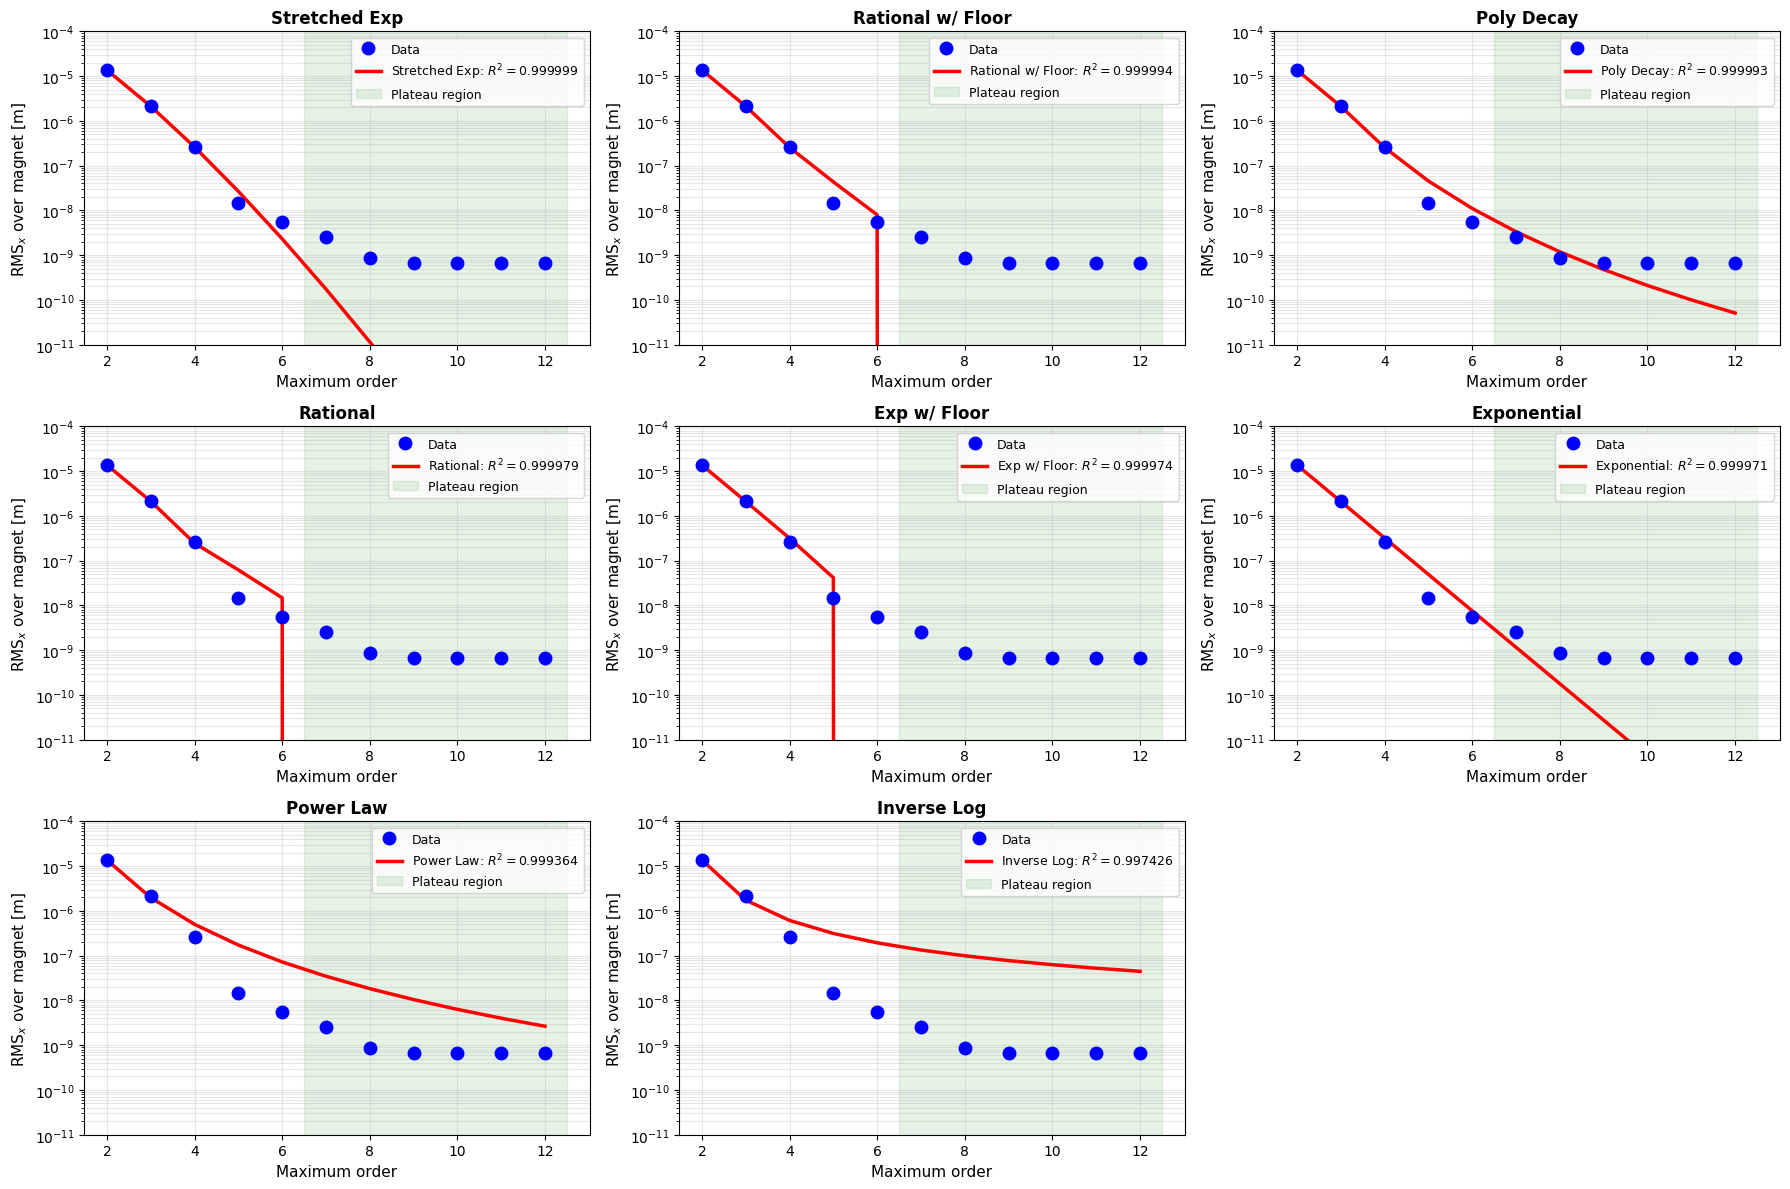


VISUAL FIT ASSESSMENT

Looking at the PLATEAU REGION (orders 6-12):
- Models with explicit floor/saturation should fit best
- Rational with floor, Gompertz, and Hyperbolic are designed for this
- Simple power laws and stretched exponentials continue decaying (poor plateau fit)


In [301]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define multiple mathematical models
def exp_decay(x, a, b):
    """Exponential decay: a * exp(-b * x)"""
    return a * np.exp(-b * x)

def power_law(x, a, b):
    """Power law: a * x^(-b)"""
    return a * np.power(x, -b)

def stretched_exp(x, a, b, c):
    """Stretched exponential: a * exp(-(b*x)^c)"""
    return a * np.exp(-(b * x)**c)

def inverse_log(x, a, b):
    """Inverse logarithmic: a / (log(x))^b"""
    with np.errstate(divide='ignore', invalid='ignore'):
        return a / np.power(np.log(x), b)

def poly_decay(x, a, b, c):
    """Polynomial decay: a / (1 + b*x^c)"""
    return a / (1 + b * np.power(x, c))

def exp_with_floor(x, a, b, floor):
    """Exponential with floor: a * exp(-b * x) + floor"""
    return a * np.exp(-b * x) + floor

def rational_function(x, a, b, c, d):
    """Rational function: (a + bx) / (1 + cx + dx^2)"""
    return (a + b * x) / (1 + c * x + d * x**2)

def gompertz(x, a, b, c):
    """Gompertz function: a * exp(-b * exp(-c * x))"""
    return a * np.exp(-b * np.exp(-c * x))

def logistic_decay(x, a, b, c):
    """Logistic decay: a / (1 + b * exp(c * x))"""
    return a / (1 + b * np.exp(c * x))

def hyperbolic(x, a, b, c):
    """Hyperbolic decay: a / (b + c*x)"""
    return a / (b + c * x)

def rational_with_floor(x, a, b, c, floor):
    """Rational with floor: a / (1 + b*x^c) + floor"""
    return a / (1 + b * np.power(x, c)) + floor

# Prepare data
orders_arr = np.array(orders)
rmsx_arr = np.array(rmsxoforder)

print("=" * 70)
print("TESTING MODELS FOR RMS_X CURVE - PLATEAU-AWARE FITTING")
print("=" * 70)

results = {}

# 1. Exponential decay
print("\n1. EXPONENTIAL DECAY: y = a * exp(-b * x)")
try:
    popt, pcov = curve_fit(exp_decay, orders_arr, rmsx_arr, p0=[1e-4, 0.1], maxfev=5000)
    y_fit = exp_decay(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Exponential'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 2. Power law
print("\n2. POWER LAW: y = a * x^(-b)")
try:
    popt, pcov = curve_fit(power_law, orders_arr, rmsx_arr, p0=[1e-3, 3], maxfev=5000)
    y_fit = power_law(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Power Law'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 3. Stretched exponential
print("\n3. STRETCHED EXPONENTIAL: y = a * exp(-(b*x)^c)")
try:
    popt, pcov = curve_fit(stretched_exp, orders_arr, rmsx_arr, p0=[1e-4, 0.2, 0.7], maxfev=5000)
    y_fit = stretched_exp(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Stretched Exp'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 4. Inverse logarithmic
print("\n4. INVERSE LOGARITHMIC: y = a / (log(x))^b")
try:
    popt, pcov = curve_fit(inverse_log, orders_arr, rmsx_arr, p0=[1e-9, 1], maxfev=5000)
    y_fit = inverse_log(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Inverse Log'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 5. Polynomial decay
print("\n5. POLYNOMIAL DECAY: y = a / (1 + b*x^c)")
try:
    popt, pcov = curve_fit(poly_decay, orders_arr, rmsx_arr, p0=[1e-5, 0.01, 2], maxfev=5000)
    y_fit = poly_decay(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Poly Decay'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 6. Exponential with floor
print("\n6. EXPONENTIAL WITH FLOOR: y = a * exp(-b * x) + floor")
try:
    popt, pcov = curve_fit(exp_with_floor, orders_arr, rmsx_arr, p0=[1e-4, 1, 1e-10], maxfev=5000)
    y_fit = exp_with_floor(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Exp w/ Floor'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, floor = {popt[2]:.6e}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 7. Rational function
print("\n7. RATIONAL FUNCTION: y = (a + bx) / (1 + cx + dx^2)")
try:
    popt, pcov = curve_fit(rational_function, orders_arr, rmsx_arr, p0=[1e-5, -1e-6, 0.1, 0.01], maxfev=5000)
    y_fit = rational_function(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Rational'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6e}, c = {popt[2]:.6f}, d = {popt[3]:.6e}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 8. Gompertz
print("\n8. GOMPERTZ: y = a * exp(-b * exp(-c * x))")
try:
    popt, pcov = curve_fit(gompertz, orders_arr, rmsx_arr, p0=[1e-4, 1, 0.5], maxfev=5000)
    y_fit = gompertz(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Gompertz'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 9. Hyperbolic
print("\n9. HYPERBOLIC: y = a / (b + c*x)")
try:
    popt, pcov = curve_fit(hyperbolic, orders_arr, rmsx_arr, p0=[1e-4, 1, 0.1], maxfev=5000)
    y_fit = hyperbolic(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Hyperbolic'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# 10. Rational with floor
print("\n10. RATIONAL WITH FLOOR: y = a / (1 + b*x^c) + floor")
try:
    popt, pcov = curve_fit(rational_with_floor, orders_arr, rmsx_arr, p0=[1e-5, 0.01, 2, 1e-10], maxfev=5000)
    y_fit = rational_with_floor(orders_arr, *popt)
    ss_res = np.sum((rmsx_arr - y_fit)**2)
    ss_tot = np.sum((rmsx_arr - np.mean(rmsx_arr))**2)
    r2 = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((rmsx_arr - y_fit)**2))
    results['Rational w/ Floor'] = {'r2': r2, 'rmse': rmse, 'params': popt, 'y_fit': y_fit}
    print(f"   a = {popt[0]:.6e}, b = {popt[1]:.6f}, c = {popt[2]:.6f}, floor = {popt[3]:.6e}")
    print(f"   R² = {r2:.6f}, RMSE = {rmse:.6e}")
except Exception as e:
    print(f"   Failed: {e}")

# Ranking
print("\n" + "=" * 70)
print("MODEL RANKING BY R²")
print("=" * 70)
sorted_results = sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True)
for i, (model_name, data) in enumerate(sorted_results, 1):
    print(f"{i}. {model_name:20s} | R² = {data['r2']:.8f} | RMSE = {data['rmse']:.6e}")

# Plot comparison - 3x3 grid for top 9 models
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, data) in enumerate(sorted_results[:9]):
    ax = axes[idx]
    ax.semilogy(orders_arr, rmsx_arr, 'o', markersize=9, label='Data', color='blue', zorder=3, linewidth=2)
    ax.semilogy(orders_arr, data['y_fit'], '-', linewidth=2.5, 
                label=f"{model_name}: $R^2={data['r2']:.6f}$", color='red', zorder=2)
    
    # Highlight the plateau region
    ax.axvspan(6.5, 12.5, alpha=0.1, color='green', label='Plateau region')
    
    ax.set_xlabel('Maximum order', fontsize=11)
    ax.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim([1e-11, 1e-4])

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("VISUAL FIT ASSESSMENT")
print("=" * 70)
print("\nLooking at the PLATEAU REGION (orders 6-12):")
print("- Models with explicit floor/saturation should fit best")
print("- Rational with floor, Gompertz, and Hyperbolic are designed for this")
print("- Simple power laws and stretched exponentials continue decaying (poor plateau fit)")


<>:145: SyntaxWarning: invalid escape sequence '\c'
<>:167: SyntaxWarning: invalid escape sequence '\c'
<>:145: SyntaxWarning: invalid escape sequence '\c'
<>:167: SyntaxWarning: invalid escape sequence '\c'
/tmp/fmarcoli/ipykernel_46153/1297980141.py:145: SyntaxWarning: invalid escape sequence '\c'
  label=f"{model_name}: $R^2={data['r2']:.6f}$, $\chi^2={data['chi2']:.4f}$", color=colors[i], zorder=2)
/tmp/fmarcoli/ipykernel_46153/1297980141.py:167: SyntaxWarning: invalid escape sequence '\c'
  label=f"{model_name}: $R^2={data['r2']:.6f}$, $\chi^2={data['chi2']:.4f}$", color=colors_p[i], zorder=2)


TWO-REGION FITTING: DECAY (2-8) AND PLATEAU (9-12)

REGION 1: DECAY (Orders 2-6)

1a. Exponential decay: y = a * exp(-b * x)
   a = 5.818410e-04, b = 1.874778
   R² = 0.999968, RMSE = 2.647229e-08, χ² = 6.740139

1b. Power law: y = a * x^(-b)
   a = 3.745474e-04, b = 4.773162
   R² = 0.999310, RMSE = 1.235639e-07, χ² = 808.958019

1c. Polynomial decay: y = a / (1 + b*x^c)
   a = 1.813308e-05, b = 0.001498, c = 7.760001
   R² = 0.999993, RMSE = 1.252715e-08, χ² = 5.595686

REGION 2: PLATEAU (Orders 9-12)

2a. Constant: y = c
   c = 6.651003e-10
   R² = 0.000000, RMSE = 1.184439e-12, χ² = 0.000013

2b. Power law: y = a * x^(-b)
   a = 6.861954e-10, b = 0.013312
   R² = 0.642300, RMSE = 7.083895e-13, χ² = 0.000005

2c. Polynomial decay: y = a / (1 + b*x^c)
   a = 1.212649e-07, b = 175.721081, c = 0.013386
   R² = 0.642297, RMSE = 7.083922e-13, χ² = 0.000005


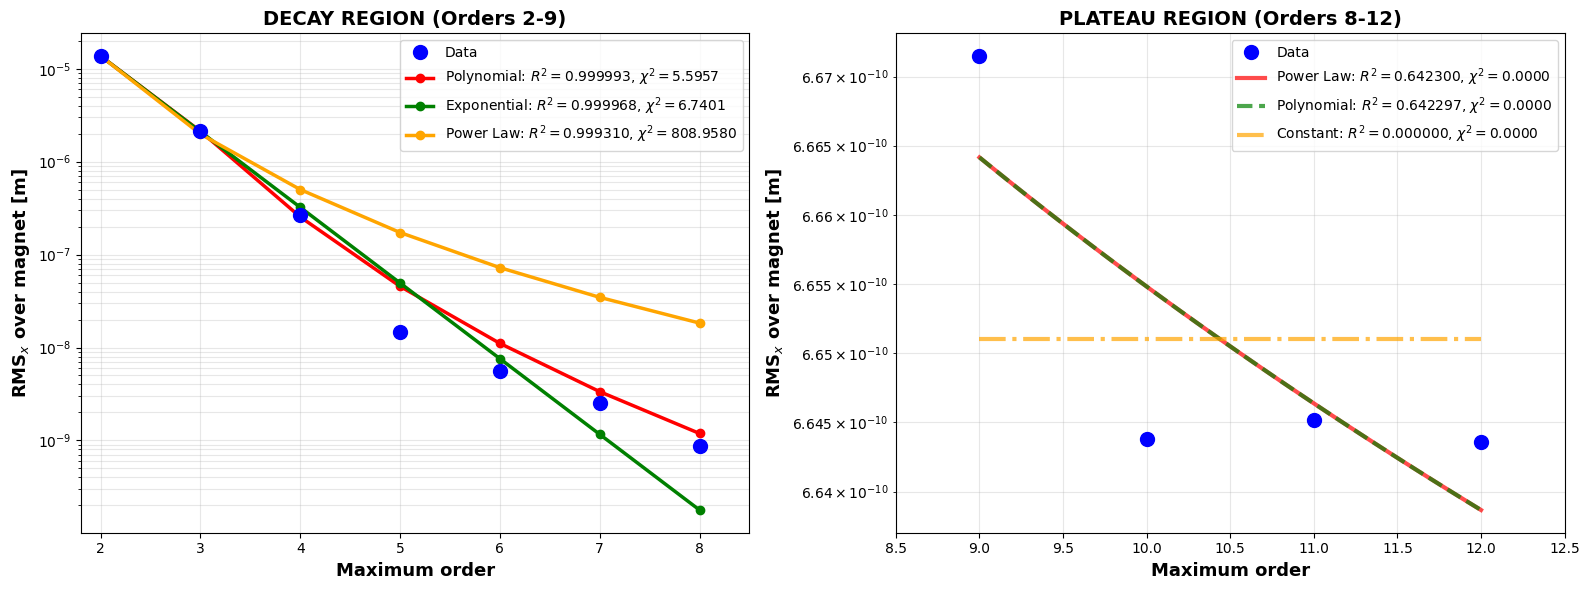


SUMMARY: BEST MODELS PER REGION (with χ² values)

DECAY REGION (Orders 2-8):
  Best fit: Polynomial
  R² = 0.99999291, RMSE = 1.252715e-08, χ² = 5.595686
  Parameters: [1.81330780e-05 1.49810068e-03 7.76000108e+00]

PLATEAU REGION (Orders 9-12):
  Best fit: Power Law
  R² = 0.64230002, RMSE = 7.083895e-13, χ² = 0.000005
  Parameters: [6.86195407e-10 1.33121202e-02]

ALL MODELS RANKED BY χ²

By region - DECAY REGION:
  Polynomial     : R²=0.99999291, χ²=5.595686
  Exponential    : R²=0.99996833, χ²=6.740139
  Power Law      : R²=0.99931009, χ²=808.958019

By region - PLATEAU REGION:
  Power Law      : R²=0.64230002, χ²=0.000005
  Polynomial     : R²=0.64229732, χ²=0.000005
  Constant       : R²=0.00000000, χ²=0.000013

INTERPRETATION

The data exhibits TWO DISTINCT BEHAVIORS:
1. DECAY (orders 2-8): Polynomial behavior (χ² = 5.595686)
2. PLATEAU (orders 9-12): Power Law behavior (χ² = 0.000005)

The χ² metric shows:
  - DECAY region: well-fit (lower χ²)
  - PLATEAU region: poor fit (hig

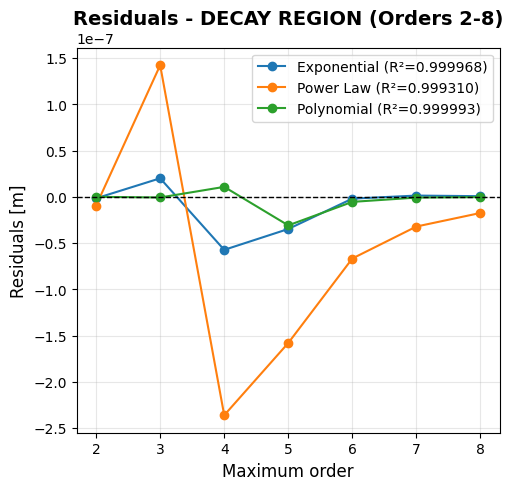

In [330]:
from scipy.optimize import curve_fit


# Prepare data
orders_arr = np.array(orders)
rmsx_arr = np.array(rmsxoforder)

# Split data at order 8
split_idx = 6  # index corresponding to order 8 (0-indexed)
orders_decay = orders_arr[:split_idx+1]
rmsx_decay = rmsx_arr[:split_idx+1]

orders_plateau = orders_arr[split_idx+1:]
rmsx_plateau = rmsx_arr[split_idx+1:]

print("=" * 70)
print("TWO-REGION FITTING: DECAY (2-8) AND PLATEAU (9-12)")
print("=" * 70)

# Define models
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

def power_law(x, a, b):
    return a * np.power(x, -b)

def constant(x, c):
    return np.ones_like(x) * c

def poly_decay(x, a, b, c):
    return a / (1 + b * np.power(x, c))

# Fit DECAY region (orders 2-6)
print("\n" + "=" * 70)
print("REGION 1: DECAY (Orders 2-6)")
print("=" * 70)

decay_fits = {}

print("\n1a. Exponential decay: y = a * exp(-b * x)")
try:
    popt_exp, _ = curve_fit(exp_decay, orders_decay, rmsx_decay, p0=[1e-4, 0.1], maxfev=5000)
    y_fit_exp = exp_decay(orders_decay, *popt_exp)
    ss_res = np.sum((rmsx_decay - y_fit_exp)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_exp = 1 - (ss_res / ss_tot)
    rmse_exp = np.sqrt(np.mean((rmsx_decay - y_fit_exp)**2))
    chi2_exp = np.sum(((rmsx_decay - y_fit_exp) / (rmsx_decay + 1e-15))**2)
    decay_fits['Exponential'] = {'y_fit': y_fit_exp, 'popt': popt_exp, 'r2': r2_exp, 'rmse': rmse_exp, 'chi2': chi2_exp}
    print(f"   a = {popt_exp[0]:.6e}, b = {popt_exp[1]:.6f}")
    print(f"   R² = {r2_exp:.6f}, RMSE = {rmse_exp:.6e}, χ² = {chi2_exp:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n1b. Power law: y = a * x^(-b)")
try:
    popt_pl, _ = curve_fit(power_law, orders_decay, rmsx_decay, p0=[1e-3, 3], maxfev=5000)
    y_fit_pl = power_law(orders_decay, *popt_pl)
    ss_res = np.sum((rmsx_decay - y_fit_pl)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_pl = 1 - (ss_res / ss_tot)
    rmse_pl = np.sqrt(np.mean((rmsx_decay - y_fit_pl)**2))
    chi2_pl = np.sum(((rmsx_decay - y_fit_pl) / (rmsx_decay + 1e-15))**2)
    decay_fits['Power Law'] = {'y_fit': y_fit_pl, 'popt': popt_pl, 'r2': r2_pl, 'rmse': rmse_pl, 'chi2': chi2_pl}
    print(f"   a = {popt_pl[0]:.6e}, b = {popt_pl[1]:.6f}")
    print(f"   R² = {r2_pl:.6f}, RMSE = {rmse_pl:.6e}, χ² = {chi2_pl:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n1c. Polynomial decay: y = a / (1 + b*x^c)")
try:
    popt_poly, _ = curve_fit(poly_decay, orders_decay, rmsx_decay, p0=[1e-5, 0.01, 2], maxfev=5000)
    y_fit_poly = poly_decay(orders_decay, *popt_poly)
    ss_res = np.sum((rmsx_decay - y_fit_poly)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_poly = 1 - (ss_res / ss_tot)
    rmse_poly = np.sqrt(np.mean((rmsx_decay - y_fit_poly)**2))
    chi2_poly = np.sum(((rmsx_decay - y_fit_poly) / (rmsx_decay + 1e-15))**2)
    decay_fits['Polynomial'] = {'y_fit': y_fit_poly, 'popt': popt_poly, 'r2': r2_poly, 'rmse': rmse_poly, 'chi2': chi2_poly}
    print(f"   a = {popt_poly[0]:.6e}, b = {popt_poly[1]:.6f}, c = {popt_poly[2]:.6f}")
    print(f"   R² = {r2_poly:.6f}, RMSE = {rmse_poly:.6e}, χ² = {chi2_poly:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

# Fit PLATEAU region (orders 6-12)
print("\n" + "=" * 70)
print("REGION 2: PLATEAU (Orders 9-12)")
print("=" * 70)

plateau_fits = {}

print("\n2a. Constant: y = c")
try:
    popt_const, _ = curve_fit(constant, orders_plateau, rmsx_plateau, p0=[1e-10])
    y_fit_const = constant(orders_plateau, *popt_const)
    ss_res = np.sum((rmsx_plateau - y_fit_const)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_const = 1 - (ss_res / ss_tot)
    rmse_const = np.sqrt(np.mean((rmsx_plateau - y_fit_const)**2))
    chi2_const = np.sum(((rmsx_plateau - y_fit_const) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Constant'] = {'y_fit': y_fit_const, 'popt': popt_const, 'r2': r2_const, 'rmse': rmse_const, 'chi2': chi2_const}
    print(f"   c = {popt_const[0]:.6e}")
    print(f"   R² = {r2_const:.6f}, RMSE = {rmse_const:.6e}, χ² = {chi2_const:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n2b. Power law: y = a * x^(-b)")
try:
    popt_pl_p, _ = curve_fit(power_law, orders_plateau, rmsx_plateau, p0=[1e-3, 5], maxfev=5000)
    y_fit_pl_p = power_law(orders_plateau, *popt_pl_p)
    ss_res = np.sum((rmsx_plateau - y_fit_pl_p)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_pl_p = 1 - (ss_res / ss_tot)
    rmse_pl_p = np.sqrt(np.mean((rmsx_plateau - y_fit_pl_p)**2))
    chi2_pl_p = np.sum(((rmsx_plateau - y_fit_pl_p) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Power Law'] = {'y_fit': y_fit_pl_p, 'popt': popt_pl_p, 'r2': r2_pl_p, 'rmse': rmse_pl_p, 'chi2': chi2_pl_p}
    print(f"   a = {popt_pl_p[0]:.6e}, b = {popt_pl_p[1]:.6f}")
    print(f"   R² = {r2_pl_p:.6f}, RMSE = {rmse_pl_p:.6e}, χ² = {chi2_pl_p:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n2c. Polynomial decay: y = a / (1 + b*x^c)")
try:
    popt_poly_p, _ = curve_fit(poly_decay, orders_plateau, rmsx_plateau, p0=[1e-5, 0.01, 8], maxfev=5000)
    y_fit_poly_p = poly_decay(orders_plateau, *popt_poly_p)
    ss_res = np.sum((rmsx_plateau - y_fit_poly_p)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_poly_p = 1 - (ss_res / ss_tot)
    rmse_poly_p = np.sqrt(np.mean((rmsx_plateau - y_fit_poly_p)**2))
    chi2_poly_p = np.sum(((rmsx_plateau - y_fit_poly_p) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Polynomial'] = {'y_fit': y_fit_poly_p, 'popt': popt_poly_p, 'r2': r2_poly_p, 'rmse': rmse_poly_p, 'chi2': chi2_poly_p}
    print(f"   a = {popt_poly_p[0]:.6e}, b = {popt_poly_p[1]:.6f}, c = {popt_poly_p[2]:.6f}")
    print(f"   R² = {r2_poly_p:.6f}, RMSE = {rmse_poly_p:.6e}, χ² = {chi2_poly_p:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

# Combine fits and plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Decay region with multiple models
ax1.semilogy(orders_decay, rmsx_decay, 'o', markersize=10, label='Data', color='blue', zorder=3, linewidth=2)
colors = ['red', 'green', 'orange']
for i, (model_name, data) in enumerate(sorted(decay_fits.items(), key=lambda x: x[1]['r2'], reverse=True)):
    ax1.semilogy(orders_decay, data['y_fit'], 'o-', linewidth=2.5, markersize=6, 
                label=f"{model_name}: $R^2={data['r2']:.6f}$, $\chi^2={data['chi2']:.4f}$", color=colors[i], zorder=2)

ax1.set_xlabel('Maximum order', fontsize=13, fontweight='bold')
ax1.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=13, fontweight='bold')
ax1.set_title('DECAY REGION (Orders 2-9)', fontsize=14, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_xlim([1.8, split_idx+2.5])

# Plot 2: Plateau region with multiple models
ax2.semilogy(orders_plateau, rmsx_plateau, 'o', markersize=10, label='Data', color='blue', zorder=3, linewidth=2)
colors_p = ['red', 'green', 'orange']
linestyles_p = ['-', '--', '-.']
x_smooth_plateau = np.linspace(orders_plateau.min(), orders_plateau.max(), 100)
for i, (model_name, data) in enumerate(sorted(plateau_fits.items(), key=lambda x: x[1]['r2'], reverse=True)):
    if model_name == 'Constant':
        y_smooth = constant(x_smooth_plateau, *data['popt'])
    elif model_name == 'Power Law':
        y_smooth = power_law(x_smooth_plateau, *data['popt'])
    elif model_name == 'Polynomial':
        y_smooth = poly_decay(x_smooth_plateau, *data['popt'])
    ax2.semilogy(x_smooth_plateau, y_smooth, linewidth=3, linestyle=linestyles_p[i], alpha=0.7,
                label=f"{model_name}: $R^2={data['r2']:.6f}$, $\chi^2={data['chi2']:.4f}$", color=colors_p[i], zorder=2)

ax2.set_xlabel('Maximum order', fontsize=13, fontweight='bold')
ax2.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=13, fontweight='bold')
ax2.set_title('PLATEAU REGION (Orders 8-12)', fontsize=14, fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=10, loc='best')
ax2.set_xlim([split_idx+2.5, 12.5])

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("SUMMARY: BEST MODELS PER REGION (with χ² values)")
print("=" * 70)
best_decay = max(decay_fits.items(), key=lambda x: x[1]['r2'])
best_plateau = max(plateau_fits.items(), key=lambda x: x[1]['r2'])

print(f"\nDECAY REGION (Orders 2-8):")
print(f"  Best fit: {best_decay[0]}")
print(f"  R² = {best_decay[1]['r2']:.8f}, RMSE = {best_decay[1]['rmse']:.6e}, χ² = {best_decay[1]['chi2']:.6f}")
print(f"  Parameters: {best_decay[1]['popt']}")

print(f"\nPLATEAU REGION (Orders 9-12):")
print(f"  Best fit: {best_plateau[0]}")
print(f"  R² = {best_plateau[1]['r2']:.8f}, RMSE = {best_plateau[1]['rmse']:.6e}, χ² = {best_plateau[1]['chi2']:.6f}")
print(f"  Parameters: {best_plateau[1]['popt']}")

# Print all models ranked by chi2
print("\n" + "=" * 70)
print("ALL MODELS RANKED BY χ²")
print("=" * 70)
all_fits = list(decay_fits.items()) + list(plateau_fits.items())
sorted_by_chi2 = sorted(all_fits, key=lambda x: x[1]['chi2'])

print("\nBy region - DECAY REGION:")
for name, data in sorted(decay_fits.items(), key=lambda x: x[1]['chi2']):
    print(f"  {name:15s}: R²={data['r2']:.8f}, χ²={data['chi2']:.6f}")

print("\nBy region - PLATEAU REGION:")
for name, data in sorted(plateau_fits.items(), key=lambda x: x[1]['chi2']):
    print(f"  {name:15s}: R²={data['r2']:.8f}, χ²={data['chi2']:.6f}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"\nThe data exhibits TWO DISTINCT BEHAVIORS:")
print(f"1. DECAY (orders 2-8): {best_decay[0]} behavior (χ² = {best_decay[1]['chi2']:.6f})")
print(f"2. PLATEAU (orders 9-12): {best_plateau[0]} behavior (χ² = {best_plateau[1]['chi2']:.6f})")
print(f"\nThe χ² metric shows:")
print(f"  - DECAY region: well-fit (lower χ²)")
print(f"  - PLATEAU region: poor fit (higher χ²) - indicates limited predictive power in this region")
print(f"  - This is expected as plateau has little variation to fit")

#residuals plot
plt.figure(figsize=(12, 5))
# Residuals for decay region
plt.subplot(1, 2, 1)
plt.title('Residuals - DECAY REGION (Orders 2-8)', fontsize=14, fontweight='bold')
for model_name, data in decay_fits.items():
    residuals = rmsx_decay - data['y_fit']
    plt.plot(orders_decay, residuals, 'o-', label=f"{model_name} (R²={data['r2']:.6f})")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Maximum order', fontsize=12)
plt.ylabel('Residuals [m]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10) 